# Agentic RAG with Open-Source Endpoints

This notebook demonstrates an Agentic RAG (Retrieval-Augmented Generation) application using:
- **LLM**: `openai/gpt-oss-20b` via Together AI
- **Embeddings**: `BAAI/bge-large-en-v1.5` via Together AI
- **Framework**: LangChain and LangGraph
- **Data**: CSV and PDF files from the data/ directory


## Setup and Configuration


In [1]:
import os
import getpass
from typing import TypedDict, Annotated

# Set Together API key
if "TOGETHER_API_KEY" not in os.environ:
    os.environ["TOGETHER_API_KEY"] = getpass.getpass("Enter your Together API key: ")


In [2]:
# LangChain imports
from langchain_together import ChatTogether, TogetherEmbeddings
from langchain_community.document_loaders import PyPDFLoader, CSVLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# LangGraph imports
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool


## Load and Process Documents


In [3]:
# Load PDF document
pdf_loader = PyPDFLoader("data/howpeopleuseai.pdf")
pdf_docs = pdf_loader.load()

# Load CSV document
csv_loader = CSVLoader("data/AIE8_Projects_with_Domains.csv")
csv_docs = csv_loader.load()

# Combine all documents
all_docs = pdf_docs + csv_docs

print(f"Loaded {len(pdf_docs)} PDF pages and {len(csv_docs)} CSV rows")
print(f"Total documents: {len(all_docs)}")


Loaded 64 PDF pages and 40 CSV rows
Total documents: 104


In [4]:
# Split documents into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

splits = text_splitter.split_documents(all_docs)
print(f"Split into {len(splits)} chunks")


Split into 199 chunks


## Create Vector Store


In [5]:
# Initialize Together embeddings
embeddings = TogetherEmbeddings(
    model="BAAI/bge-large-en-v1.5"
)

# Create Chroma vector store
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    collection_name="agentic_rag_collection"
)

# Create retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print("Vector store created successfully!")


Vector store created successfully!


## Initialize LLM


In [6]:
# Initialize Together LLM
llm = ChatTogether(
    model="openai/gpt-oss-20b",
    temperature=0.7,
    max_tokens=512
)

print("LLM initialized successfully!")


LLM initialized successfully!


## Define RAG Tool


In [7]:
@tool
def retrieve_documents(query: str) -> str:
    """Retrieve relevant documents from the knowledge base based on the query.
    
    This tool searches through the document collection (including AI projects data
    and information about how people use AI) and returns relevant context.
    
    Args:
        query: The search query to find relevant documents
        
    Returns:
        A string containing the relevant document excerpts
    """
    docs = retriever.invoke(query)
    return "\n\n".join([doc.page_content for doc in docs])

# Create list of tools
tools = [retrieve_documents]

# Bind tools to LLM
llm_with_tools = llm.bind_tools(tools)

print("Tools defined and bound to LLM!")


Tools defined and bound to LLM!


## Build Agentic RAG with LangGraph


In [8]:
# Define the state
class State(TypedDict):
    messages: Annotated[list, add_messages]

print("State defined!")


State defined!


In [9]:
# Define the chatbot node
def chatbot(state: State):
    """Main chatbot node that processes messages and decides whether to use tools."""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

print("Chatbot node defined!")


Chatbot node defined!


In [10]:
# Build the graph
graph_builder = StateGraph(State)

# Add nodes
graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

# Add edges
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Compile the graph
graph = graph_builder.compile()

print("LangGraph agent compiled successfully!")


LangGraph agent compiled successfully!


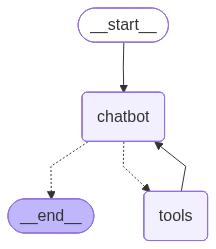

In [11]:
# Visualize the graph (optional)
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not visualize graph: {e}")
    print("Graph structure: START -> chatbot -> [tools (optional)] -> END")


## Test the Agentic RAG


In [12]:
def ask_question(question: str):
    """Helper function to ask questions to the agent."""
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print(f"{'='*60}\n")
    
    messages = [{"role": "user", "content": question}]
    result = graph.invoke({"messages": messages})
    
    # Get the final AI message
    for message in reversed(result["messages"]):
        if hasattr(message, 'content') and message.content and not hasattr(message, 'tool_calls'):
            print(f"Answer: {message.content}")
            break
    
    print(f"\n{'='*60}\n")
    return result


In [13]:
# Test query 1: About the documents
result1 = ask_question("What are some of the AIE8 projects mentioned in the documents?")



Question: What are some of the AIE8 projects mentioned in the documents?

Answer: Proceedings of the National Academy of Sciences, 2025,122(1), e2414972121.
Ide, Enrique and Eduard Talamas, “Artificial Intelligence in the Knowledge Economy,”Journal
of Political Economy, June 2025,9(122), null.
Korinek, Anton and Donghyun Suh, “Scenarios for the Transition to AI,” Technical Report
32255, National Bureau of Economic Research, Cambridge, MA March 2024.
Kulveit, Jan, Raymond Douglas, Nora Ammann, Deger Turan, David Krueger, and
David Duvenaud, “Gradual Disempowerment: Systemic Existential Risks from Incremental AI
Development,” 2025.
Lambert, Nathan, Jacob Morrison, Valentina Pyatkin, Shengyi Huang, Hamish Ivison,
Faeze Brahman, Lester James V Miranda, Alisa Liu, Nouha Dziri, Shane Lyu et al.,
“Tulu 3: Pushing frontiers in open language model post-training,”arXiv preprint arXiv:2411.15124,
2024.
Ling, Yier and Alex Imas, “Underreporting of AI use: The role of social desirability bias,”htt

In [14]:
# Test query 2: About AI usage
result2 = ask_question("How do people use AI according to the documents?")



Question: How do people use AI according to the documents?

Answer: 6 Who Uses ChatGPT
In this section we report basic descriptive facts about who uses consumer ChatGPT. Existing work
documents variation in generative AI use by demographic groups within representative samples in
the U.S. (Bick et al. (2024), Hartley et al. (2025)) and within a subset of occupations in Denmark
(Humlum and Vestergaard, 2025a). All of these papers find that generative AI is used more frequently
by men, young people, and those with tertiary and/or graduate education.
We make three contributions relative to this prior literature. First, we confirm these broad demo-
graphic patterns in a global sample rather than a single country. Second, we provide more detail for
selected demographics such as age, gender, and country of origin and study how gaps in each have
changed over time. Third, we use a secure data clean room to analyze how ChatGPT usage varies by
education and occupation.
6.1 Name Analysis

1 Intro

In [15]:
# Test query 3: General question (shouldn't need retrieval)
result3 = ask_question("What is machine learning?")



Question: What is machine learning?

Answer: What is machine learning?




In [16]:
# Test query 4: Specific to the data
result4 = ask_question("What domains are covered in the AIE8 projects?")



Question: What domains are covered in the AIE8 projects?

Answer: Your Name: Omar Kahwaji
What is the title of your project?: AI PM Interviewer
Project Domain: HR / Recruiting
Secondary Domain (if any): Developer Tools / DevEx

Your Name: Germee
What is the title of your project?: Roni AI - Your AI CFO
Project Domain: Finance / FinTech
Secondary Domain (if any): Developer Tools / DevEx

Your Name: Molly Li
What is the title of your project?: Promptable.ai
Project Domain: Developer Tools / DevEx
Secondary Domain (if any): Creative / Design / Media




In [17]:
# Interactive chat loop
print("Agentic RAG Chat Interface")
print("Type 'quit' or 'exit' to stop\n")

while True:
    user_input = input("You: ").strip()
    
    if user_input.lower() in ['quit', 'exit', 'q']:
        print("Goodbye!")
        break
    
    if not user_input:
        continue
    
    try:
        messages = [{"role": "user", "content": user_input}]
        result = graph.invoke({"messages": messages})
        
        # Get the final AI message
        for message in reversed(result["messages"]):
            if hasattr(message, 'content') and message.content and not hasattr(message, 'tool_calls'):
                print(f"\nAgent: {message.content}\n")
                break
    except Exception as e:
        print(f"Error: {e}\n")


Agentic RAG Chat Interface
Type 'quit' or 'exit' to stop


Agent: Your Name: Germee
What is the title of your project?: Roni AI - Your AI CFO
Project Domain: Finance / FinTech
Secondary Domain (if any): Developer Tools / DevEx

Your Name: Monica
What is the title of your project?: CareBridge
Project Domain: Writing & Content
Secondary Domain (if any): Productivity Assistants

Your Name: Ovo Okpubuluku
What is the title of your project?: InvestigatorAI (A Multi-Agent Fraud Investigation System)
Project Domain: Security
Secondary Domain (if any): Research & Knowledge

Goodbye!


## Cleanup

Remember to clean up resources when done!


In [18]:
# Clean up the vector store
# vectorstore.delete_collection()
print("Session complete! Remember to shutdown any Together AI endpoints if you created dedicated ones.")


Session complete! Remember to shutdown any Together AI endpoints if you created dedicated ones.
